In [8]:
using ITensors, ITensorMPS, Plots
include("../../data/params.jl")
include("../../data/helpers/saving.jl")
include("../schmidt_spectra/get_spectrum.jl")
include("../schmidt_spectra/deviation/deviation.jl")

   Resolving package versions...
     Project No packages added to or removed from `~/dev/uni/msciproject/Project.toml`
    Manifest No packages added to or removed from `~/dev/uni/msciproject/Manifest.toml`

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


find_deviation_idx (generic function with 1 method)

In [9]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 10,
                    "MAX_BOND_DIM" => 1000,
                    "ACC" => 10^-16
                    )

run_params_cln = Dict{String, Any}(
    "N" => 40,
    "σ" => 0.00
)

run_params_dis = Dict{String, Any}(
    "N" => 40,
    "σ" => 0.002
)

CURRENT_DIR = @__DIR__
FP = extract_filename_from_system_params(system_params)
MPS_FP = path = joinpath(CURRENT_DIR, "../../data/storage/perturb_$(FP).hd5")
matches_cln = find_runs_by_params(MPS_FP, run_params_cln; load_psi=true, instance_selection=:latest)
matches_dis = find_runs_by_params(MPS_FP, run_params_dis; load_psi=true, instance_selection=:latest)

psi_cln = matches_cln[1].psi
psi_dis = matches_dis[1].psi

40-element MPS:
 ((dim=2|id=160|"S=1/2,Site,n=1") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=2|id=414|"Link,l=1") <Out>
 1: QN("Sz",-1) => 1
 2: QN("Sz",1) => 1)
 ((dim=4|id=954|"Link,l=2") <Out>
 1: QN("Sz",-2) => 1
 2: QN("Sz",0) => 2
 3: QN("Sz",2) => 1, (dim=2|id=534|"S=1/2,Site,n=2") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=2|id=414|"Link,l=1") <In>
 1: QN("Sz",-1) => 1
 2: QN("Sz",1) => 1)
 ((dim=2|id=295|"S=1/2,Site,n=3") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=8|id=988|"Link,l=3") <Out>
 1: QN("Sz",-3) => 1
 2: QN("Sz",-1) => 3
 3: QN("Sz",1) => 3
 4: QN("Sz",3) => 1, (dim=4|id=954|"Link,l=2") <In>
 1: QN("Sz",-2) => 1
 2: QN("Sz",0) => 2
 3: QN("Sz",2) => 1)
 ((dim=2|id=488|"S=1/2,Site,n=4") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=14|id=616|"Link,l=4") <Out>
 1: QN("Sz",-4) => 1
 2: QN("Sz",-2) => 4
 3: QN("Sz",0) => 4
 4: QN("Sz",2) => 4
 5: QN("Sz",4) => 1, (dim=8|id=988|"Link,l=3") <In>
 1: QN("Sz",-3) => 1
 2: QN("Sz",-1) => 

In [10]:
spec_cln = get_squared_sorted_schmidt_spectrum_from_mps(psi_cln)
spec_dis = get_squared_sorted_schmidt_spectrum_from_mps(psi_dis)

564-element Vector{Float64}:
 0.23636778855097465
 0.2363677885435781
 0.16116290580740933
 0.16116290579066836
 0.07438569485614886
 0.0743856948421449
 0.02288920537258111
 0.02288920536553503
 0.004578187513358181
 0.00457818751120801
 ⋮
 2.9925047613242983e-18
 2.9825594289075077e-18
 2.9748182232786693e-18
 2.823261102356203e-18
 2.8141358843507592e-18
 2.671758466274172e-18
 2.659249405400903e-18
 2.6023362070627925e-18
 2.422634751044706e-18

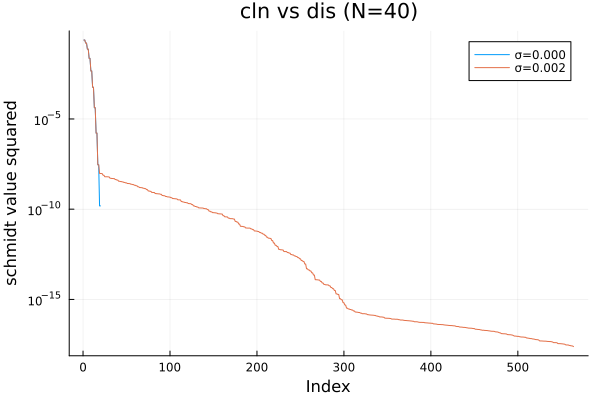

"/Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/clean_vs_disordered_N=40_sigma=0.002_acc=1.0e-16.png"

In [13]:
p_cln_vs_dis = plot(title="cln vs dis (N=40)", yscale=:log10, xlabel="Index", ylabel="schmidt value squared")

plot!(p_cln_vs_dis, 1:length(spec_cln), spec_cln, label="σ=0.000")
plot!(p_cln_vs_dis, 1:length(spec_dis), spec_dis, label="σ=0.002")

display(p_cln_vs_dis)
savefig(p_cln_vs_dis, joinpath(CURRENT_DIR, "clean_vs_disordered_N=40_sigma=0.002_acc=1.0e-16.png"))

In [16]:
ξ = inner(psi_cln, psi_dis)

0.9999997511573525

In [26]:
c = 1 / (1 - ξ)
psi_r = c * ( psi_dis - ξ * psi_cln )


40-element MPS:
 ((dim=2|id=160|"S=1/2,Site,n=1") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=4|id=102|"Link,l=1") <Out>
 1: QN("Sz",-1) => 2
 2: QN("Sz",1) => 2)
 ((dim=2|id=534|"S=1/2,Site,n=2") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=7|id=375|"Link,l=2") <Out>
 1: QN("Sz",-2) => 2
 2: QN("Sz",0) => 3
 3: QN("Sz",2) => 2, (dim=4|id=102|"Link,l=1") <In>
 1: QN("Sz",-1) => 2
 2: QN("Sz",1) => 2)
 ((dim=2|id=295|"S=1/2,Site,n=3") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=12|id=261|"Link,l=3") <Out>
 1: QN("Sz",-3) => 2
 2: QN("Sz",-1) => 4
 3: QN("Sz",1) => 4
 4: QN("Sz",3) => 2, (dim=7|id=375|"Link,l=2") <In>
 1: QN("Sz",-2) => 2
 2: QN("Sz",0) => 3
 3: QN("Sz",2) => 2)
 ((dim=2|id=488|"S=1/2,Site,n=4") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=19|id=996|"Link,l=4") <Out>
 1: QN("Sz",-4) => 2
 2: QN("Sz",-2) => 5
 3: QN("Sz",0) => 5
 4: QN("Sz",2) => 5
 5: QN("Sz",4) => 2, (dim=12|id=261|"Link,l=3") <In>
 1: QN("Sz",-3) => 2
 2: QN("Sz",-1) =

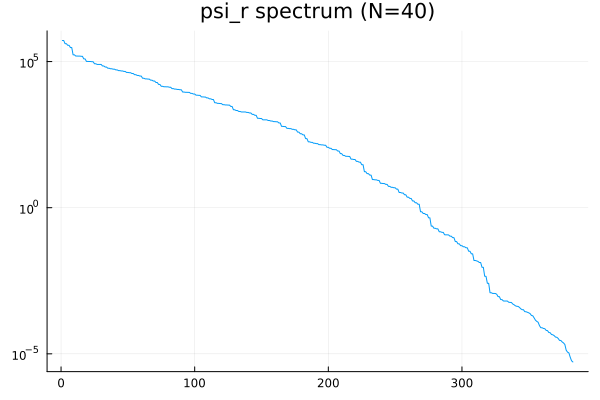

In [27]:
spec_r = get_squared_sorted_schmidt_spectrum_from_mps(psi_r)

p3 = plot(1:length(spec_r), spec_r, title="psi_r spectrum (N=40)",yscale=:log10, legend=false)